# Ensemble Mean — Michaelis-Menten
***
Accumulate trajectories from many simulations into a single `Ensemble`
and compute the mean trajectory across all runs.
***
## Setup the Environment
***

In [14]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
import os
import sys
from copy import deepcopy
sys.path.insert(1, os.path.abspath(os.path.join(os.getcwd(), '../')))

In [16]:
import gillespy3d_pp as gillespy2
import matplotlib.pyplot as plt
import numpy as np

***
## Define the Model
***

In [17]:
def create_michaelis_menten():
    model = gillespy2.Model(name="Michaelis_Menten")

    A = gillespy2.Species(name='Substrate', initial_value=301)
    B = gillespy2.Species(name='Enzyme', initial_value=120)
    C = gillespy2.Species(name='Enzyme_Substrate_Complex', initial_value=0)
    D = gillespy2.Species(name='Product', initial_value=0)
    model.add_species([A, B, C, D])

    rate1 = gillespy2.Parameter(name='rate1', expression=0.0017)
    rate2 = gillespy2.Parameter(name='rate2', expression=0.5)
    rate3 = gillespy2.Parameter(name='rate3', expression=0.1)
    model.add_parameter([rate1, rate2, rate3])

    r1 = gillespy2.Reaction(
        name="r1", reactants={'Substrate': 1, 'Enzyme': 1},
        products={'Enzyme_Substrate_Complex': 1}, rate='rate1'
    )
    r2 = gillespy2.Reaction(
        name="r2", reactants={'Enzyme_Substrate_Complex': 1},
        products={'Substrate': 1, 'Enzyme': 1}, rate='rate2'
    )
    r3 = gillespy2.Reaction(
        name="r3", reactants={'Enzyme_Substrate_Complex': 1},
        products={'Enzyme': 1, 'Product': 1}, rate='rate3'
    )
    model.add_reaction([r1, r2, r3])

    tspan = gillespy2.TimeSpan.linspace(end_t=100, num_points=101)
    model.timespan(tspan)
    return model

In [18]:
model = create_michaelis_menten()

***
## Build the Ensemble Across Multiple Simulations
***
Each call to `sim.run()` returns a `Result` containing some number of
trajectories. We accumulate them into a single `Ensemble` so the mean is
computed across **all** runs, not just one batch.

In [19]:
ensemble = gillespy2.Ensemble()

num_batches = 5
trajectories_per_batch = 20

for batch in range(num_batches):
    sim = gillespy2.Simulation(
        model,
        number_of_trajectories=trajectories_per_batch,
        dt=1,
        end_t=100,
        solver="TAU",
    )
    result = sim.run()
    ensemble.add_trajectories(result)
    print(f"Batch {batch + 1}: ensemble now holds {ensemble.num_trajs} trajectories")

print("\nEnsemble summary:")
print(f"  num_trajs      = {ensemble.num_trajs}")
print(f"  num_species    = {ensemble.num_species}")
print(f"  num_timepoints = {ensemble.num_timepoints}")
print(f"  data shape     = {ensemble.data.shape}")

Batch 1: ensemble now holds 20 trajectories
Batch 2: ensemble now holds 40 trajectories
Batch 3: ensemble now holds 60 trajectories
Batch 4: ensemble now holds 80 trajectories
Batch 5: ensemble now holds 100 trajectories

Ensemble summary:
  num_trajs      = 100
  num_species    = 4
  num_timepoints = 101
  data shape     = (100, 4, 101)


***
## Compute and Plot the Mean Ensemble
***

In [20]:
mean = ensemble.mean()
print("Mean shape:", mean.shape)
print("Final-time means per species:")
for name, final in zip(ensemble.species_names, mean[:, -1]):
    print(f"  {name:30s} {final:.2f}")

Mean shape: (4, 101)
Final-time means per species:
  Substrate                      27.35
  Enzyme                         111.93
  Enzyme_Substrate_Complex       8.07
  Product                        265.58


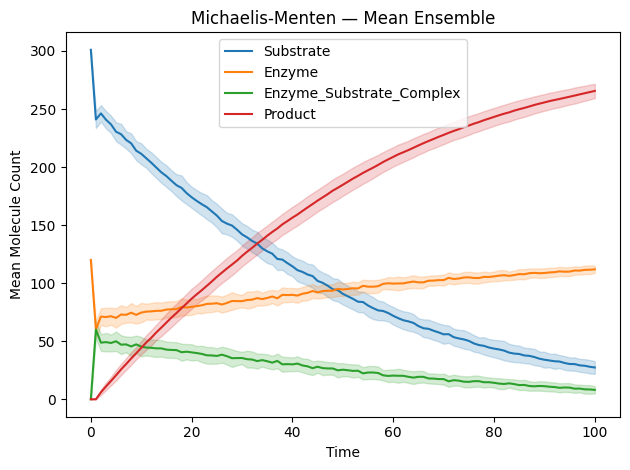

In [21]:
ensemble.plot_mean(title="Michaelis-Menten — Mean Ensemble", show_band=True)

***
## Mean vs. Individual Trajectories
***
Overlay every trajectory and the mean to confirm the mean tracks the
central tendency of the cloud.

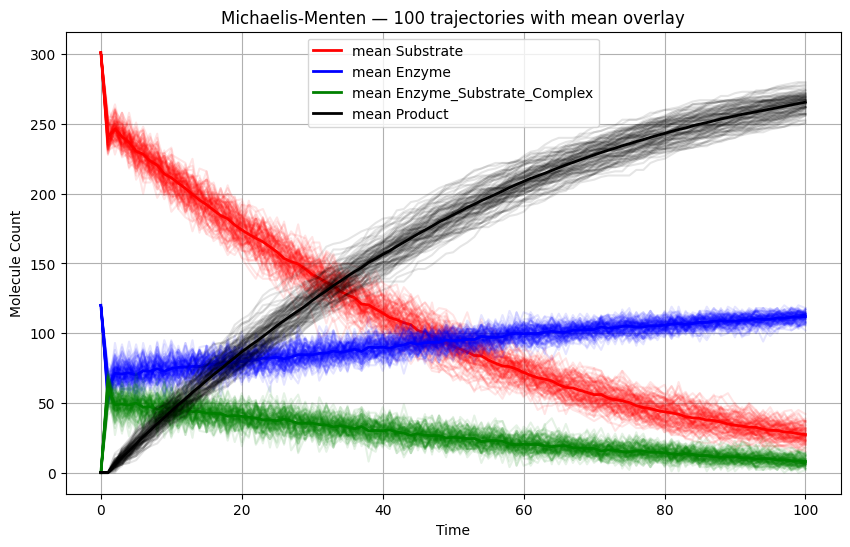

In [22]:
colors = ['red', 'blue', 'green', 'black']
mean = ensemble.mean()

plt.figure(figsize=(10, 6))
for s_idx, name in enumerate(ensemble.species_names):
    color = colors[s_idx % len(colors)]
    for t_idx in range(ensemble.num_trajs):
        plt.plot(
            ensemble.timeline,
            ensemble.data[t_idx, s_idx],
            color=color,
            alpha=0.1,
        )
    plt.plot(ensemble.timeline, mean[s_idx], color=color, linewidth=2, label=f"mean {name}")

plt.xlabel('Time')
plt.ylabel('Molecule Count')
plt.title(f'Michaelis-Menten — {ensemble.num_trajs} trajectories with mean overlay')
plt.legend()
plt.grid(True)
plt.show()

***
## Validate Against an Analytical Solution — Exponential Decay
***
First-order decay has a closed-form solution

$$N(t) = N_0 \, e^{-kt}$$

We build a decay ensemble, then evaluate the analytical formula at the
exact timepoints the simulation recorded so the two curves can be compared
point-for-point.

In [23]:
def create_exponential_decay(initial_pop=1_000_000, decay_rate=10.0):
    model = gillespy2.Model(name="Exponential_Decay")

    A = gillespy2.Species(name='A', initial_value=initial_pop)
    model.add_species([A])

    k = gillespy2.Parameter(name='k', expression=decay_rate)
    model.add_parameter([k])

    decay = gillespy2.Reaction(
        name="decay", reactants={'A': 1}, products={}, rate='k'
    )
    model.add_reaction([decay])

    tspan = gillespy2.TimeSpan.linspace(end_t=1, num_points=201)
    model.timespan(tspan)
    return model

In [27]:
N0 = 1_000_000
k  = 10.0

# Sweep from very conservative (near-SSA) to very aggressive leaping
#epsilons = [0.001, 0.01, 0.05, 0.1, 0.3, 0.5]
epsilons = [ 0.1]

decay_model = create_exponential_decay(initial_pop=N0, decay_rate=k)
ensembles = {}

for eps in epsilons:
    ens = gillespy2.Ensemble()
    for batch in range(3):
        sim = gillespy2.Simulation(
            decay_model,
            number_of_trajectories=10,
            dt=0.005,
            end_t=1,
            solver="TAU",
        )
        sim.solver.epsilon = eps
        ens.add_trajectories(sim.run())
    ensembles[eps] = ens
    print(f"ε={eps}: {ens.num_trajs} trajectories collected")

ε=0.1: 30 trajectories collected


In [29]:
def analytical_decay(N0, k, t):
    """Closed-form first-order decay: N(t) = N0 * exp(-k*t).

    Parameters
    ----------
    N0 : float
        Initial molecule count.
    k : float
        Rate constant.
    t : array-like
        Timepoints at which to evaluate N(t).
    """
    return N0 * np.exp(-k * np.asarray(t))


# All ensembles share the same timeline; evaluate the analytical curve once.
t = next(iter(ensembles.values())).timeline
analytical = analytical_decay(N0, k, t)

print(f"Analytical evaluated at {len(t)} timepoints")
print(f"  N({t[0]:.3f}) = {analytical[0]:.0f}")
print(f"  N({t[len(t)//2]:.3f}) = {analytical[len(t)//2]:.0f}")
print(f"  N({t[-1]:.3f}) = {analytical[-1]:.0f}")

Analytical evaluated at 201 timepoints
  N(0.000) = 1000000
  N(0.500) = 6738
  N(1.000) = 45


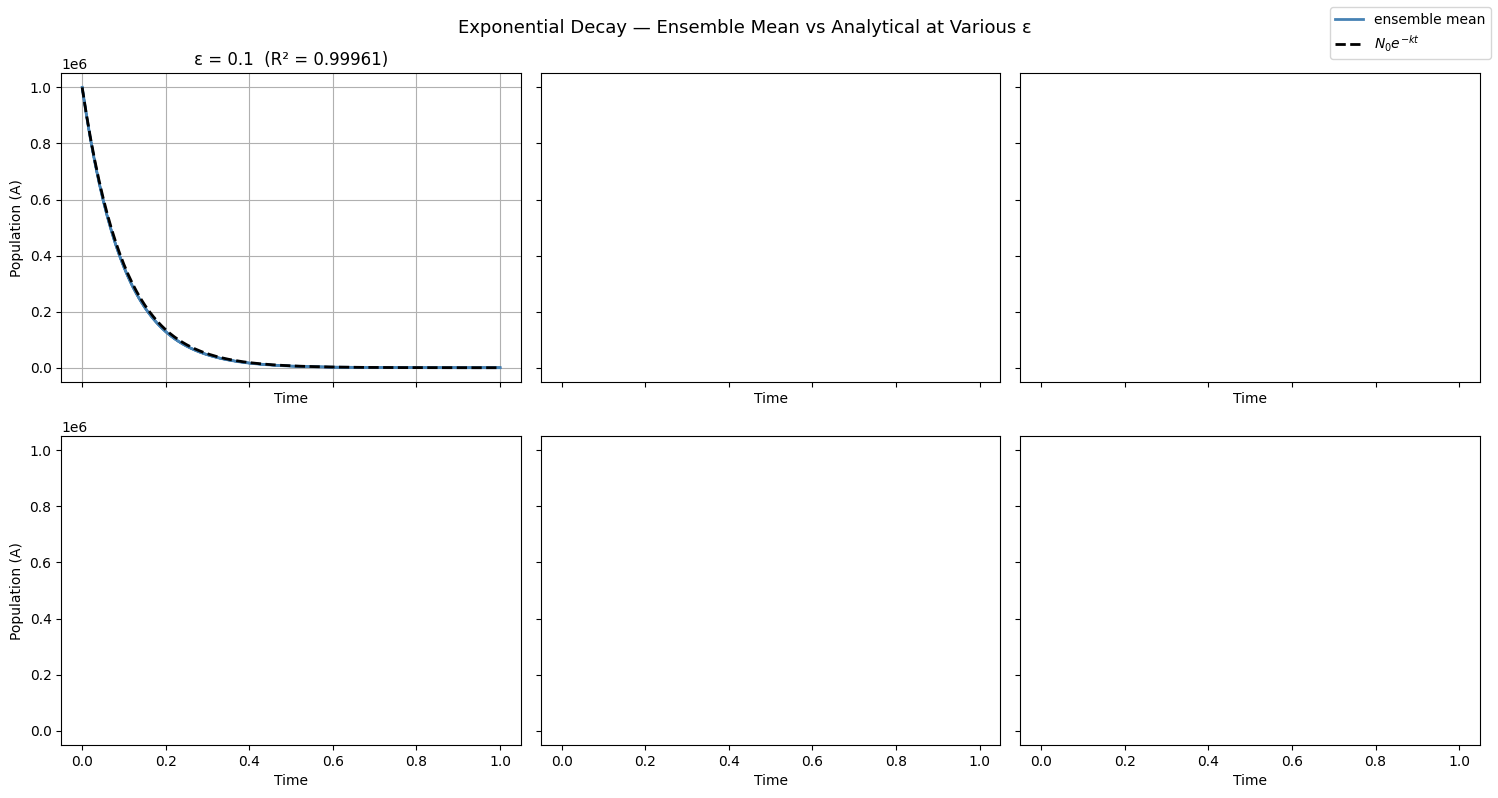


       ε          R²
----------------------
     0.1    0.999615


In [30]:
ss_tot = np.sum((analytical - analytical.mean()) ** 2)
r2_results = {}

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, (eps, ens) in zip(axes, ensembles.items()):
    mean_decay = ens.mean()[0]
    residual = mean_decay - analytical
    r2 = 1 - np.sum(residual ** 2) / ss_tot
    r2_results[eps] = r2

    for t_idx in range(ens.num_trajs):
        ax.plot(ens.timeline, ens.data[t_idx, 0], color='steelblue', alpha=0.15)
    ax.plot(ens.timeline, mean_decay, color='steelblue', linewidth=2, label='ensemble mean')
    ax.plot(t, analytical, 'k--', linewidth=2, label=r'$N_0 e^{-kt}$')
    ax.set_title(f'\u03b5 = {eps}  (R\u00b2 = {r2:.5f})')
    ax.grid(True)

for ax in axes:
    ax.set_xlabel('Time')
axes[0].set_ylabel('Population (A)')
axes[3].set_ylabel('Population (A)')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')
fig.suptitle('Exponential Decay \u2014 Ensemble Mean vs Analytical at Various \u03b5', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\n{'\u03b5':>8}  {'R\u00b2':>10}")
print('-' * 22)
for eps, r2 in r2_results.items():
    print(f'{eps:>8}  {r2:>10.6f}')